# Smart Home Anonymisation — Fixed Notebook

This notebook is a **fixed, runnable** version tailored for the Smart Home Dataset with Weather Information (Kaggle). It:

- Loads a CSV from ./data/ or a custom path
- Preprocesses numeric sensor columns and creates sliding windows
- Trains a 1D Convolutional Autoencoder (CAE) on windows
- Evaluates privacy (MSE, cosine similarity, SSIM via 2D patch conversion)
- Evaluates utility (classification accuracy) on a downstream task
- Applies FGSM adversarial perturbations to reconstructed windows
- Shows visualizations (loss curve, original vs reconstructed, FGSM effect)

**Notes before running**:
- Install dependencies: pip install torch torchvision numpy pandas scikit-learn matplotlib scikit-image tslearn
- Place the Kaggle CSV in ./data/ (e.g. ./data/smart_home.csv) or update the CSV_PATH variable.

Let's run step-by-step.

## 0) Install requirements (run once)

If running in Colab or a fresh environment, run this cell first:

In [ ]:
!pip install --quiet torch torchvision numpy pandas scikit-learn matplotlib scikit-image tslearn

In [1]:
# Imports & device
import os, math, time, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from scipy.spatial.distance import cosine

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [2]:
# 1) Load dataset (update CSV_PATH if needed)
CSV_PATH = 'smart_home.csv'  # <-- update if your file has a different name or folder

if not os.path.exists(CSV_PATH):
    print('CSV not found at', CSV_PATH)
    print('Please download the Kaggle Smart Home dataset and place the main CSV at that path.')
else:
    print('Found CSV:', CSV_PATH)

# Try to read CSV robustly
try:
    df = pd.read_csv(CSV_PATH, low_memory=False)
    print('CSV loaded, shape:', df.shape)
except Exception as e:
    print('Failed to load CSV:', e)
    df = None

# If CSV failed to load, create a small synthetic dataset to allow running the notebook
if df is None or df.shape[0] < 500:
    print('Using synthetic demo data (so the notebook is runnable).')
    rng = np.random.RandomState(42)
    n = 20000
    t = pd.date_range('2020-01-01', periods=n, freq='T')
    df = pd.DataFrame({
        'timestamp': t,
        'Appliances': np.abs(rng.normal(1.0, 0.7, size=n)),
        'Temperature': rng.normal(20, 2, size=n),
        'Humidity': rng.normal(50, 5, size=n),
        'Light': np.abs(rng.normal(100, 30, size=n)),
        'CO2': np.abs(rng.normal(400, 50, size=n)),
        'RH_out': rng.normal(10, 2, size=n)
    })
    CSV_PATH = None

print('Dataframe columns sample:', df.columns.tolist()[:20])

Found CSV: smart_home.csv
CSV loaded, shape: (503911, 32)
Dataframe columns sample: ['time', 'use [kW]', 'gen [kW]', 'House overall [kW]', 'Dishwasher [kW]', 'Furnace 1 [kW]', 'Furnace 2 [kW]', 'Home office [kW]', 'Fridge [kW]', 'Wine cellar [kW]', 'Garage door [kW]', 'Kitchen 12 [kW]', 'Kitchen 14 [kW]', 'Kitchen 38 [kW]', 'Barn [kW]', 'Well [kW]', 'Microwave [kW]', 'Living room [kW]', 'Solar [kW]', 'temperature']


In [3]:
# 2) Preprocessing: select numeric columns and build sliding windows
# Parameters (tune as needed)
SEQ_LEN = 128   # length of each window (timesteps)
STEP = 64       # sliding step

# Choose numeric columns automatically (drop timestamp-like candidates)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
drop_candidates = [c for c in numeric_cols if 'unnamed' in c.lower() or c.lower().startswith('index')]
numeric_cols = [c for c in numeric_cols if c not in drop_candidates]

# If too many columns, keep first 8 to keep models small by default
if len(numeric_cols) > 8:
    numeric_cols = numeric_cols[:8]

print('Selected numeric columns:', numeric_cols)

# Build numpy array and fill missing values
data = df[numeric_cols].fillna(method='ffill').fillna(method='bfill').astype(float).values
print('Raw data shape:', data.shape)

# Standardize features (per feature)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Sliding windows generation: shape -> (N_windows, SEQ_LEN, n_features)
windows = []
for start in range(0, len(data_scaled) - SEQ_LEN + 1, STEP):
    windows.append(data_scaled[start:start+SEQ_LEN])
windows = np.stack(windows).astype(np.float32)
print('Generated windows shape:', windows.shape)

# Create a simple binary target for utility (high mean of first feature in window)
feature0 = df[numeric_cols[0]].fillna(method='ffill').fillna(method='bfill').values
y_series = feature0
labels = []
for start in range(0, len(y_series) - SEQ_LEN + 1, STEP):
    win = y_series[start:start+SEQ_LEN]
    labels.append(int(win.mean() > np.percentile(y_series, 75)))
labels = np.array(labels)

# Train/val/test split (by windows)
idx = np.arange(len(windows))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.1, random_state=42)

X_train = windows[train_idx]; X_val = windows[val_idx]; X_test = windows[test_idx]
y_train = labels[train_idx]; y_val = labels[val_idx]; y_test = labels[test_idx]

print('Train/Val/Test shapes:', X_train.shape, X_val.shape, X_test.shape)

Selected numeric columns: ['use [kW]', 'gen [kW]', 'House overall [kW]', 'Dishwasher [kW]', 'Furnace 1 [kW]', 'Furnace 2 [kW]', 'Home office [kW]', 'Fridge [kW]']
Raw data shape: (503911, 8)
Generated windows shape: (7872, 128, 8)


C:\Users\mario\AppData\Local\Temp\ipykernel_13356\816578606.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = df[numeric_cols].fillna(method='ffill').fillna(method='bfill').astype(float).values
C:\Users\mario\AppData\Local\Temp\ipykernel_13356\816578606.py:33: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  feature0 = df[numeric_cols[0]].fillna(method='ffill').fillna(method='bfill').values


Train/Val/Test shapes: (5667, 128, 8) (630, 128, 8) (1575, 128, 8)


In [4]:
# PyTorch Dataset & DataLoaders
class WindowDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.from_numpy(X)  # (N, T, F)
        self.y = None if y is None else torch.from_numpy(y).long()
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

batch_size = 64
train_loader = DataLoader(WindowDataset(X_train, y_train), batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(WindowDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(WindowDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

print('Batches per epoch (train):', len(train_loader))

Batches per epoch (train): 88


In [5]:
# 3) 1D Convolutional Autoencoder
class CAE1D(nn.Module):
    def __init__(self, n_features, seq_len, latent_dim=64):
        super().__init__()
        self.seq_len = seq_len
        self.encoder = nn.Sequential(
            nn.Conv1d(n_features, 32, kernel_size=5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1), nn.ReLU()
        )
        # determine flattened size
        with torch.no_grad():
            dummy = torch.zeros(1, n_features, seq_len)
            z = self.encoder(dummy)
            flat = z.view(1, -1).shape[1]
        self.fc_enc = nn.Linear(flat, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, flat)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose1d(32, n_features, kernel_size=4, stride=2, padding=1)
        )
    def forward(self, x):
        # x: (B, T, F) -> (B, F, T)
        x = x.permute(0,2,1)
        z = self.encoder(x)
        zflat = z.view(z.size(0), -1)
        latent = self.fc_enc(zflat)
        dec = self.fc_dec(latent)
        dec = dec.view(z.size(0), 128, z.size(2))
        out = self.decoder(dec)
        out = out.permute(0,2,1)  # (B, T, F)
        return out, latent

n_features = X_train.shape[2]
cae = CAE1D(n_features=n_features, seq_len=SEQ_LEN, latent_dim=64).to(device)
print('CAE created with n_features=', n_features)

CAE created with n_features= 8


Epoch 5/20 — loss: 0.186106
Epoch 10/20 — loss: 0.120194
Epoch 15/20 — loss: 0.091212
Epoch 20/20 — loss: 0.076916


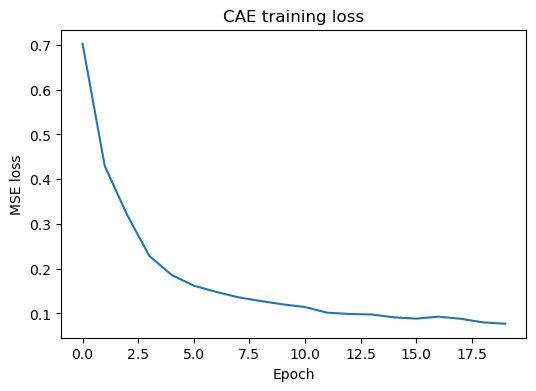

In [6]:
# 4) Train CAE
num_epochs = 20
optimizer = optim.Adam(cae.parameters(), lr=1e-3)
criterion = nn.MSELoss()
train_losses = []
for epoch in range(num_epochs):
    cae.train()
    running = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        xr, _ = cae(xb)
        loss = criterion(xr, xb)
        loss.backward()
        optimizer.step()
        running += loss.item()
    avg = running / len(train_loader)
    train_losses.append(avg)
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}/{num_epochs} — loss: {avg:.6f}')

# plot training loss
plt.figure(figsize=(6,4))
plt.plot(train_losses)
plt.title('CAE training loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.show()

In [7]:
# 5) Reconstruction on all windows and privacy metrics
cae.eval()
with torch.no_grad():
    all_X = torch.from_numpy(windows).to(device)
    all_recon_tensor, _ = cae(all_X)
    all_recon = all_recon_tensor.cpu().numpy()

# Compute MSE over windows
mse_windows = np.mean((windows - all_recon)**2, axis=(1,2))
mean_mse = mse_windows.mean()

# Cosine similarity per window
cosines = []
for i in range(len(windows)):
    cosines.append(1 - cosine(windows[i].flatten(), all_recon[i].flatten()))
mean_cosine = np.mean(cosines)

# SSIM: convert each window to 2D patch and compute
def window_to_patch(win):
    arr = win.T
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    arr_res = resize(arr, (128,128), anti_aliasing=True, preserve_range=True)
    return arr_res

ssim_vals = []
K = min(200, len(windows))
for i in range(K):
    p1 = window_to_patch(windows[i])
    p2 = window_to_patch(all_recon[i])
    try:
        s = ssim(p1, p2, data_range=p1.max()-p1.min())
    except Exception:
        s = 0.0
    ssim_vals.append(s)
mean_ssim = float(np.mean(ssim_vals))

print('Privacy metrics:')
print('Mean MSE:', mean_mse)
print('Mean cosine similarity:', mean_cosine)
print('Mean SSIM (first', K, 'windows):', mean_ssim)

Privacy metrics:
Mean MSE: 0.08447356
Mean cosine similarity: 0.9550219
Mean SSIM (first 200 windows): 0.7546800955888253


In [10]:
# 6) Utility evaluation: classifier on original vs reconstructed windows
class ConvClassifier(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_features, 32, 5, 2, 2), nn.ReLU(),
            nn.Conv1d(32, 64, 5, 2, 2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        x = x.permute(0,2,1)
        return self.net(x)

clf = ConvClassifier(n_features=n_features).to(device)
opt_clf = optim.Adam(clf.parameters(), lr=1e-3)
loss_clf = nn.CrossEntropyLoss()

# prepare tensors for training classifier on original windows (train set)
Xtr = torch.from_numpy(X_train).to(device)
ytr = torch.from_numpy(y_train).long().to(device)
Xte = torch.from_numpy(X_test).to(device)
yte = torch.from_numpy(y_test).long().to(device)

# train classifier quickly
for epoch in range(10):
    clf.train()
    logits = clf(Xtr)
    loss = loss_clf(logits, ytr)
    opt_clf.zero_grad(); loss.backward(); opt_clf.step()

# evaluate on original test set
clf.eval()
with torch.no_grad():
    ypred = torch.argmax(clf(Xte), dim=1).cpu().numpy()
orig_acc = accuracy_score(y_test, ypred)

# evaluate on reconstructed test set
recon_test = all_recon[test_idx]
with torch.no_grad():
    ypred_recon = torch.argmax(clf(torch.from_numpy(recon_test).to(device)), dim=1).cpu().numpy()
recon_acc = accuracy_score(y_test, ypred_recon)

print('Utility (accuracy): original test acc =', orig_acc, 'reconstructed test acc =', recon_acc)

Utility (accuracy): original test acc = 0.8025396825396826 reconstructed test acc = 0.820952380952381


Accuracy on adversarially perturbed reconstructions = 0.8


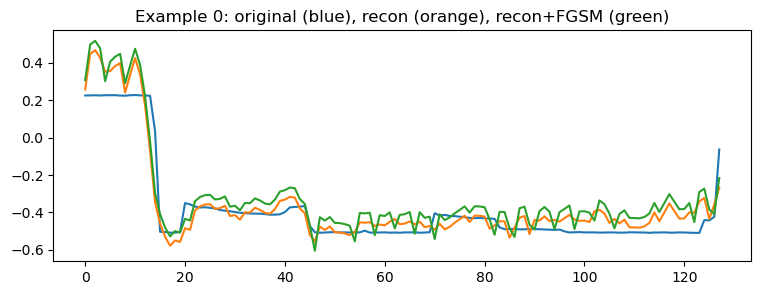

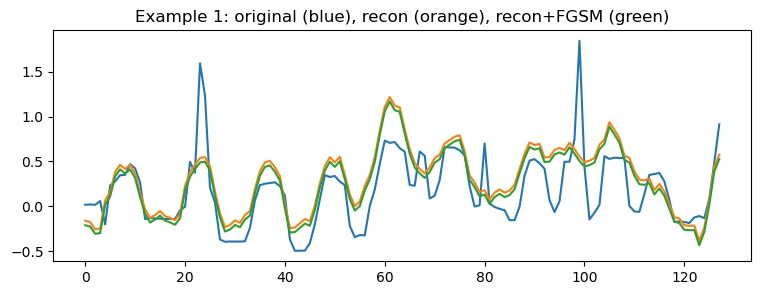

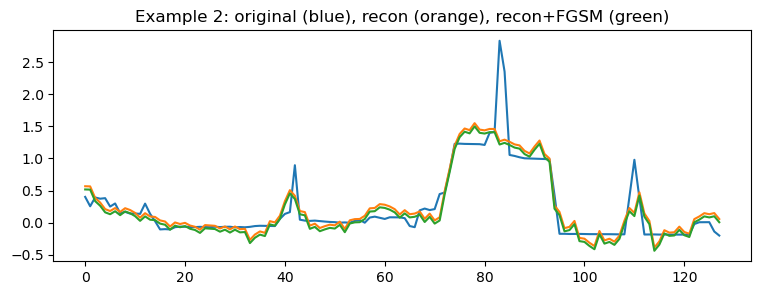

In [11]:
# 7) FGSM adversarial perturbation on reconstructed test windows
# We'll compute a single-step FGSM perturbation on reconstructions to reduce classifier accuracy
epsilon = 0.05
clf.eval()

recon_tensor = torch.tensor(recon_test, dtype=torch.float32, device=device, requires_grad=True)
labels_tensor = torch.tensor(y_test, dtype=torch.long, device=device)

logits = clf(recon_tensor)
loss_adv = loss_clf(logits, labels_tensor)
loss_adv.backward()
recon_adv = recon_tensor + epsilon * recon_tensor.grad.sign()
recon_adv = recon_adv.detach().cpu().numpy()

# Evaluate classifier on adversarial reconstructions
with torch.no_grad():
    ypred_adv = torch.argmax(clf(torch.from_numpy(recon_adv).to(device)), dim=1).cpu().numpy()
adv_acc = accuracy_score(y_test, ypred_adv)
print('Accuracy on adversarially perturbed reconstructions =', adv_acc)

# Visualize examples (original window signal vs recon vs recon+fgsm)
n_plot = 3
for i in range(n_plot):
    idx_i = test_idx[i]
    plt.figure(figsize=(9,3))
    plt.plot(windows[idx_i,:,0])
    plt.plot(all_recon[idx_i,:,0])
    plt.plot(recon_adv[i,:,0])
    plt.title(f'Example {i}: original (blue), recon (orange), recon+FGSM (green)')
    plt.show()